# 3.2 Replica Exchange and the Melting of a Cluster

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume III — Molecular Dynamics",
    number="3.2",
    title="Replica Exchange and the Melting of a Cluster",
    blurb="The sampling problem of rugged landscapes, the parallel-tempering "
    "algorithm that solves it by swapping configurations between temperatures, and "
    "its payoff in the real LAMMPS run of the course: the caloric curve and "
    "heat-capacity peak that locate the melting of a 38-atom argon cluster.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 12 (replica exchange)",
)

<ECP header: 2863 chars of HTML>

## Notebook overview

A single molecular-dynamics trajectory has a blind spot. On a rugged landscape,
with deep minima separated by high barriers, a low-temperature run never has the
energy to climb out of the basin it starts in, so its averages depend on where it
began. The previous notebook met this as the trapping of an optimization; here it
becomes the central problem of *sampling*. The fix is elegant: run many copies of
the system at different temperatures at once, and let them trade configurations.
The hot copies cross barriers freely, the cold copies inherit those crossings
through the swaps, and the whole set samples the landscape far better than any one
of them could alone. This is **replica exchange**, or **parallel tempering**.

This is the exercise from Lecture 12, and we take it in two steps. First we build
the algorithm on a system simple enough to see exactly what it does: a double well,
where a single chain stays stuck on one side and parallel tempering visits both.
Then we turn to the course's real result. The original ran a 38-atom argon cluster
in **LAMMPS** with twelve replicas spanning 2 to 40 K, and from the committed output
we reconstruct the **caloric curve** and the **heat-capacity peak** that pin down
the cluster's melting temperature.

> **Provenance.** This notebook develops **Lecture 12** of the course (replica
> exchange / parallel tempering, ensembles, and the heat capacity), an exercise
> **designed by the author (Raymond Amador)**. The original
> ran a LAMMPS parallel-tempering simulation (the `replica-exchange.lammps` script
> shown in Exercise 3) on the Euler cluster and *committed its output*; the
> caloric curve in Exercises 4 and 5 is reconstructed from those twelve real
> replica logs by pooling each processor's potential energy by the reference
> temperature it occupied. The algorithm itself is reproduced in Python. The full
> course credit is in the footer.

> **Reading a validation.** Each exercise closes with a check against something
> independent: an exact Boltzmann population, the monotonicity of a caloric curve,
> the known melting range of the cluster. A ✗ flags a mismatch to track down, not a
> verdict; a ✓ is strong evidence, not proof.

> **Units and scope.** The double-well demo uses dimensionless energy and
> temperature. The cluster data is from a real argon run, so energies are in eV and
> temperature in kelvin; with the deck's $\varepsilon=0.01042\,$eV $=120.9\,k_B$K
> the reduced temperature is $T^\*=T/120.9$. For methods see Allen & Tildesley
> {cite}`allen-tildesley` and Frenkel & Smit {cite}`frenkel-smit`; the
> velocity-rescaling thermostat used in the run is Bussi *et al.* {cite}`bussi2007`.

## Theory in brief

### The sampling problem

A Monte Carlo or molecular-dynamics simulation at temperature $T$ samples the
Boltzmann distribution $P(\mathbf x)\propto e^{-E(\mathbf x)/k_BT}$. To cross a
barrier of height $\Delta E$ it must wait a time $\sim e^{\Delta E/k_BT}$, which at
low temperature is astronomically long. The simulation is then **non-ergodic** on
any practical timescale: it explores only the basin it started in, and its averages
are wrong.

### Parallel tempering

**Replica exchange** runs $M$ copies of the system at temperatures
$T_1<T_2<\dots<T_M$ simultaneously. Each evolves under ordinary dynamics, and
periodically two replicas at adjacent temperatures attempt to **swap**
configurations. The swap is accepted with a Metropolis criterion that preserves
detailed balance for the joint ensemble:

```{math}
:label: eq-swap
p_{\rm acc} = \min\!\Big(1,\; e^{(\beta_i-\beta_j)(E_i-E_j)}\Big),
\qquad \beta = \frac{1}{k_BT}.
```

A configuration that wandered over a barrier at high temperature can then descend,
swap by swap, to low temperature, so each replica samples its Boltzmann
distribution while drawing on the barrier-crossing power of the hot ones. The
temperatures are spaced (often geometrically) so that neighbouring energy
distributions overlap and swaps are accepted often enough.

### Thermodynamics from the temperatures

Running every temperature at once hands us a thermodynamic sweep for free. The
average energy as a function of temperature is the **caloric curve** $\langle
E\rangle(T)$, and its slope is the **heat capacity**

```{math}
:label: eq-cv
C_v = \frac{d\langle E\rangle}{dT}.
```

A finite cluster melts over a narrow temperature range where the energy rises
steeply, so $C_v$ shows a peak there: the cluster's melting temperature, read
straight off the curve.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

rng = np.random.default_rng(0)
INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"


def double_well(x, a=5.0):
    """Symmetric double-well potential U(x) = a(x² - 1)².

    Parameters
    ----------
    x : float or numpy.ndarray
        Position(s).
    a : float, optional
        Barrier height at x = 0 (default 5.0); the minima sit at x = ±1.

    Returns
    -------
    float or numpy.ndarray
        The potential energy.
    """
    return a * (x * x - 1.0) ** 2


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "03-molecular-dynamics", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_swap_log():
    """Read the LAMMPS temper (replica-swap) log.

    Returns
    -------
    tuple of numpy.ndarray
        ``(steps, idx)``: the step column and ``idx[t, p]``, the temperature
        index that replica p occupies at recorded step t.
    """
    rows = np.loadtxt(data_file("replica-logs/swap.log"))
    return rows[:, 0], rows[:, 1:].astype(int)


def read_replica_log(p):
    """Read one replica's per-step thermodynamic log.

    Parameters
    ----------
    p : int
        Replica index (0-11).

    Returns
    -------
    numpy.ndarray
        Columns ``[Step, Temp, PotEng]`` for that replica.
    """
    return np.loadtxt(data_file(f"replica-logs/replica_{p:02d}.log"))

## Exercise 1 — The trapping problem

Take the symmetric double well $U(x)=a(x^2-1)^2$ with $a=5$, two basins at
$x=\pm1$ split by a barrier of height $5$. At a low temperature $T=0.25$ the
Boltzmann distribution is symmetric, so a correct sampler should spend half its
time in each basin. A single Metropolis chain started in the right basin does not:
crossing the barrier costs $e^{5/0.25}=e^{20}$, so it stays put for the entire run,
and its sampled distribution is wrong by a factor of two.

**Part a)** Implement a Metropolis chain `mc_chain`. **Part b)** Run it cold from
the right basin and confirm it is trapped.

findfont: Failed to find font weight 600, now using 700.


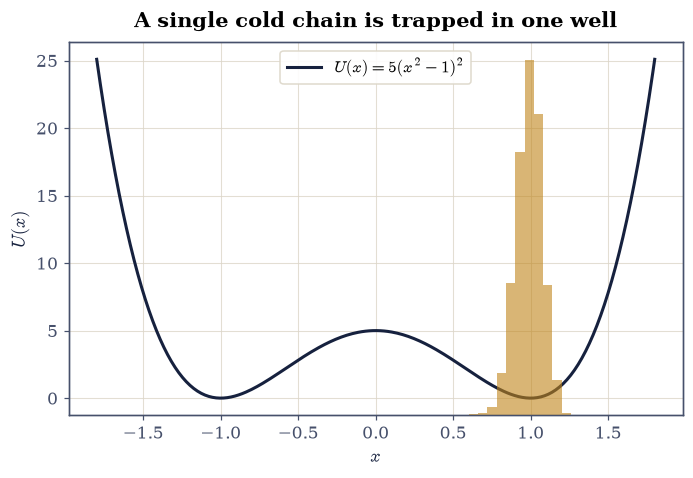

In [3]:
# (solution hidden on the public site)


### Validation 1 — the single chain is non-ergodic

Started in the right basin ($x>0$), the cold chain must spend essentially all its
time there: a fraction near one, not the correct one-half.

In [4]:
validate.check(frac_single > 0.9, "a single cold Metropolis chain stays trapped in one well",
               f"fraction with x>0 = {frac_single:.3f}")

✓  a single cold Metropolis chain stays trapped in one well   [fraction with x>0 = 1.000]


True

## Exercise 2 — Parallel tempering escapes the barrier

Now run several replicas at once, from a cold $T_1=0.25$ up to a hot $T_M=4$ where
the barrier is easily crossed, and attempt swaps between adjacent temperatures with
the criterion {eq}`eq-swap`. A configuration that crosses the barrier in a hot
replica can be swapped down to the cold one, so the cold replica, the one we care
about, finally samples *both* wells. Because the potential is symmetric, the exact
Boltzmann answer is one-half in each, and parallel tempering recovers it.

**Part a)** Implement `parallel_tempering`, returning the cold replica's samples.
**Part b)** Confirm the cold replica now populates both wells equally.

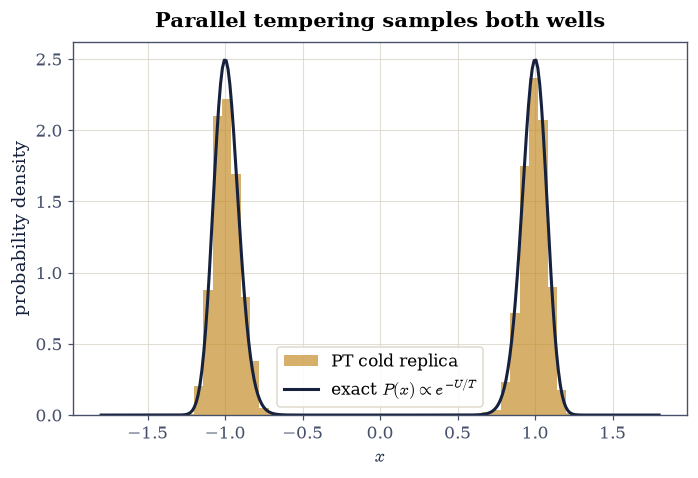

In [5]:
# (solution hidden on the public site)


### Validation 2 — the cold replica now samples both wells equally

With the swaps in place, the cold replica must populate the two symmetric wells
with equal weight, the exact Boltzmann result: a fraction near one-half.

In [6]:
validate.close(frac_pt, 0.5, "parallel tempering recovers the exact symmetric Boltzmann populations", atol=0.12)

✓  parallel tempering recovers the exact symmetric Boltzmann populations   [got 0.4975 vs expected 0.5 (rtol=1e-06)]


True

## Exercise 3 — The real run: LAMMPS parallel tempering of an argon cluster

The course applied exactly this algorithm to a 38-atom argon cluster in LAMMPS,
with twelve replicas. The temperatures are spread geometrically from 2 K to 40 K, a
harmonic wall confines the cluster so atoms cannot evaporate at the hot end, and an
exchange is attempted every 1000 steps:

```text
variable t world  2.00 2.60 3.64 5 6.63 9.12 12.07 16 21.97 26.83 32.76 40.00
pair_style lj/cut 8.5
pair_coeff 1 1 0.01042 3.405 8.5      # argon: epsilon = 0.01042 eV, sigma = 3.405 A
fix 1 all nvt temp $t $t 0.1          # a different target temperature per replica
fix 2 all wall/region rs harmonic 2.0 0.0 0.4   # spherical confinement
temper 5000000 1000 $t 1 3678 3490    # attempt an exchange every 1000 MD steps
```

The full script ships with this notebook: {download}`replica-exchange.lammps <data/replica-exchange.lammps>`.
Postprocessing the output is the crux. Each processor holds a configuration whose
*temperature* changes as swaps are accepted, so to recover the canonical average at
a fixed temperature we pool every processor's potential energy by the reference
temperature it occupied at that step, read from the exchange log. We map the swaps
here, and turn them into the caloric curve in Exercise 4.

The committed output ships with this notebook: the swap log
{download}`swap.log <data/replica-logs/swap.log>` records which of the twelve
temperatures each replica occupies over time, and the twelve per-replica thermo
logs `replica_00.log … replica_11.log` hold each one's potential energy.

**Part a)** Read the swap log and plot the **temperature index versus step** for a
few replicas (Assignment 1). **Part b)** Confirm a replica random-walks across the
whole temperature ladder, the condition for parallel tempering to help.

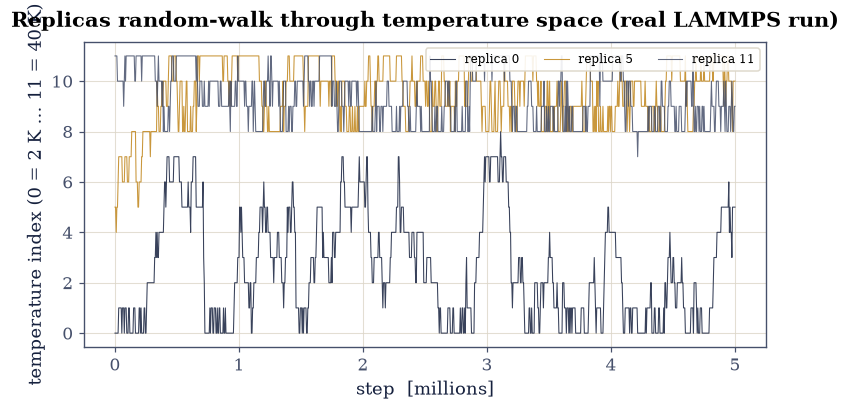

swap activity: 32.3% of steps change a replica's temperature; a tracked replica visits 5–10 of the 12 temperatures


In [7]:
# (solution hidden on the public site)


### Validation 3 — the replicas mix across temperatures

Parallel tempering only helps if configurations actually move through temperature
space. Every replica must visit a broad span of the ladder, not stay pinned at one
temperature.

In [8]:
validate.check(
    min(visited) >= 4,
    "every replica random-walks across a broad span of the temperature ladder",
    f"replicas visit {min(visited)}–{max(visited)} of 12 temperatures; swaps active on {swap_activity:.1%} of steps",
)

✓  every replica random-walks across a broad span of the temperature ladder   [replicas visit 5–10 of 12 temperatures; swaps active on 32.3% of steps]


True

## Exercise 4 — The caloric curve and the melting step

Plot the energy against temperature. Below melting the cluster is a rigid solid,
and its energy rises only gently as the atoms vibrate a little harder. Through the
melting range the structure breaks up, and the energy jumps as the latent heat goes
into disordering the cluster. That steep step, here around $T^\*\approx0.16$
($T\approx19\,$K), is the thermodynamic signature of melting, visible directly in
the caloric curve.

**Part a)** Plot $\langle E\rangle$ against $T^\*$. **Part b)** Identify the steep
(melting) section and confirm it lies in the expected range for a 38-atom
Lennard-Jones cluster, $T^\*\sim0.1$–$0.2$.

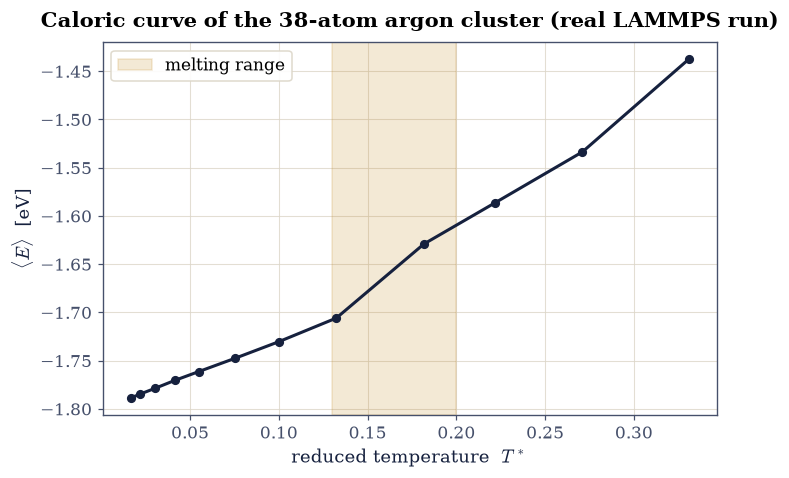

In [9]:
# (solution hidden on the public site)


### Validation 4 — melting sits where it should

The steepest rise of the caloric curve, the melting transition, must fall in the
known melting range of a 38-atom Lennard-Jones cluster, $T^\*\approx0.1$–$0.2$.

In [10]:
validate.check(
    0.10 < T_melt < 0.22,
    "the caloric curve's steepest rise locates cluster melting near T* ~ 0.16",
    f"steepest dE/dT at T* = {T_melt:.3f} (T = {T_melt*EPS_K:.0f} K)",
)

✓  the caloric curve's steepest rise locates cluster melting near T* ~ 0.16   [steepest dE/dT at T* = 0.157 (T = 19 K)]


True

## Exercise 5 — The heat-capacity peak

The heat capacity $C_v=d\langle E\rangle/dT$ {eq}`eq-cv` turns the melting step into
a peak. For a macroscopic system the peak would be a sharp divergence at a
first-order transition; for a 38-atom cluster it is a finite, rounded bump, but it
still marks the melting temperature unambiguously. This is the result the course
was built around: a thermodynamic transition measured by parallel tempering.

**Part a)** Compute $C_v$ from the caloric curve. **Part b)** Confirm its peak
coincides with the melting transition of Exercise 4.

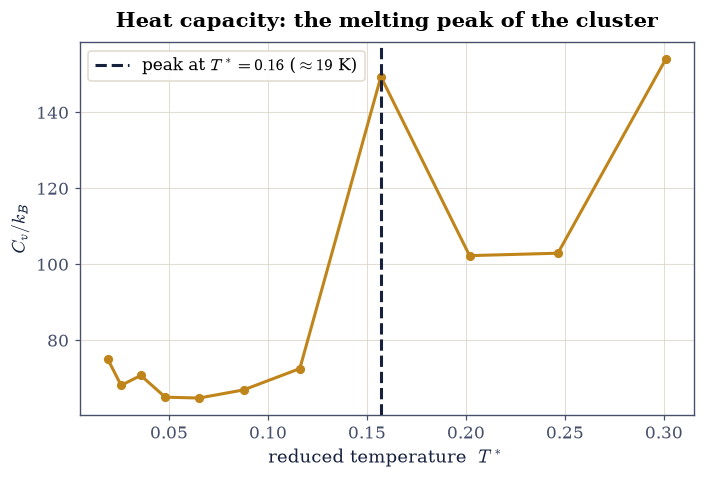

In [11]:
# (solution hidden on the public site)


### Validation 5 — the heat-capacity peak is a genuine melting transition

The melting feature must be a real *peak*: the heat capacity rises to it and falls
away on the high-temperature side, the finite-size signature of the solid melting,
not a monotonic ramp.

In [12]:
validate.check(
    Cv[i_melt] > Cv[i_melt - 1] and Cv[i_melt] > Cv[i_melt + 1],
    "C_v has a local melting peak at the caloric-curve step",
    f"C_v/k_B at T* = {T_melt:.2f}: {Cv[i_melt-1]:.1f} < {Cv[i_melt]:.1f} > {Cv[i_melt+1]:.1f}",
)

✓  C_v has a local melting peak at the caloric-curve step   [C_v/k_B at T* = 0.16: 72.5 < 149.4 > 102.3]


True

## Notebook summary

We saw why a single cold chain is trapped, then watched parallel tempering cure it:
swapping configurations up and down a temperature ladder let the cold replica
sample both wells with the correct Boltzmann weight. Applied to the course's real
twelve-replica LAMMPS run, the swap log showed each replica random-walking across
the ladder, and pooling each replica's potential energy by the temperature it
occupied reconstructed the caloric curve. Its steepest rise, a peak in the heat
capacity near $T^\ast\approx0.16$ ($\approx19\,$K), located the melting transition
of the 38-atom cluster.

## Outlook

- **Better heat capacities.** The committed run is short, so $C_v$ from energy
  *fluctuations*, $C_v=\langle E^2\rangle-\langle E\rangle^2)/k_BT^2$, is noisy here;
  the multiple-histogram (WHAM) method combines all temperatures to sharpen both the
  caloric curve and the peak.
- **The solid-solid transition.** Below melting the 38-atom cluster also converts
  between its truncated-octahedron and icosahedron forms (Volume II); a finer
  temperature grid resolves the small low-temperature heat-capacity feature this
  produces.
- **Order parameters.** Tracking the Steinhardt $Q_4$ or $Q_6$ (notebook 2.1) along
  the replicas shows the structural change *through* the transition, not just its
  energy.
- **Finding the global minimum.** Because parallel tempering crosses funnels, a low
  replica eventually settles into the global truncated octahedron that defeated the
  single-funnel basin-hopping of Volume II.

### References

```{bibliography}
:filter: docname in docnames
```

In [13]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>